<a href="https://colab.research.google.com/github/adilkamal2478/Adil_Pandas_Data_Preprocessing/blob/main/EDA_on_smartphone_data_my_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Data_processing/smartphone_cleaned_v3.csv")

In [5]:
df.shape

(921, 25)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 921 non-null    object 
 1   model                      921 non-null    object 
 2   price                      921 non-null    int64  
 3   rating                     786 non-null    float64
 4   has_5g                     921 non-null    bool   
 5   has_nfc                    921 non-null    bool   
 6   has_ir_blaster             921 non-null    bool   
 7   processor_brand            921 non-null    object 
 8   num_cores                  921 non-null    float64
 9   processor_speed            886 non-null    float64
 10  ram_capacity               921 non-null    int64  
 11  fast_charging_available    921 non-null    int64  
 12  internal_memory            921 non-null    int64  
 13  battery_capacity           921 non-null    float64

In [7]:
df.isnull().sum()

,0
brand_name,0
model,0
price,0
rating,135
has_5g,0
has_nfc,0
has_ir_blaster,0
processor_brand,0
num_cores,0
processor_speed,35


In [8]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,ram_capacity,fast_charging_available,internal_memory,battery_capacity,fast_charging,screen_size,refresh_rate,resolution,primary_camera_front,primary_camera_rear,num_rear_cameras,num_front_cameras,os,extended_memory_available,extended_upto
0,apple,Apple iPhone 18 Pro,164900,85.0,True,True,False,bionic,6.0,NaN,12,1,256,4056.0,NaN,6.30,120,1206 x 2622,18.0,48.0,3,1.0,ios,0,NaN
1,vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,True,False,True,snapdragon,8.0,2.8,8,1,256,6500.0,90.0,6.77,120,1080 x 2392,32.0,50.0,3,1.0,android,0,NaN
2,apple,Apple iPhone Duo,299900,84.0,True,True,False,bionic,6.0,NaN,12,1,256,5800.0,NaN,7.60,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
3,apple,Apple iPhone 18 Pro Max,179900,86.0,True,True,False,bionic,6.0,NaN,12,1,256,5391.0,NaN,6.90,120,1320 x 2868,18.0,48.0,3,1.0,ios,0,NaN
4,realme,Realme P1 5G (8GB RAM+ 128GB),14999,58.0,True,False,False,dimensity,8.0,2.6,8,1,128,5000.0,45.0,6.67,120,1080 x 2400,16.0,50.0,2,1.0,android,1,2048.0


# Univariate analysis

In [9]:
# brand_name

<Axes: xlabel='brand_name'>

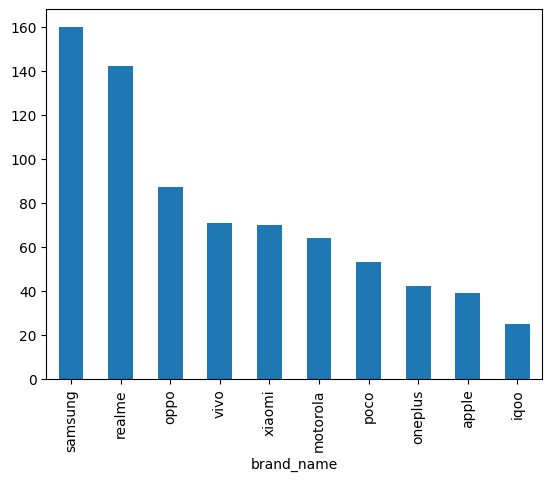

In [10]:
# plot a graph of top 10 brands
df['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

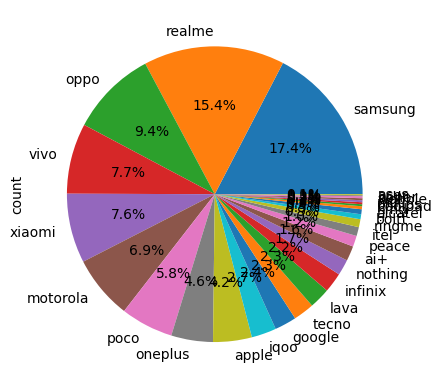

In [11]:
# pie chart
df['brand_name'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [12]:
df['brand_name'].isnull().sum()

np.int64(0)

In [13]:
# model
df['model'].nunique()

887

In [14]:
duplicates = df[df['model'].duplicated(keep=False)].sort_values('model')

duplicates[['model']]

,model
527,Ai+ Nova Flip
697,Ai+ Nova Flip
591,Google Pixel 11 Pro (16GB RAM + 512GB)
505,Google Pixel 11 Pro (16GB RAM + 512GB)
538,Motorola Edge 30 Fusion 5G
636,Motorola Edge 30 Fusion 5G
595,Motorola Moto G77 Power (4GB RAM + 128GB)
524,Motorola Moto G77 Power (4GB RAM + 128GB)
589,Motorola Moto G84 5G
537,Motorola Moto G84 5G


In [15]:
df = df.drop_duplicates(subset='model', keep='first').reset_index(drop=True)

In [16]:
df['model'].isnull().sum()

np.int64(0)

In [17]:
# price
df['price'].describe()

,price
count,887.000000
mean,42350.431793
std,45269.561128
min,5800.000000
25%,17999.000000
50%,28998.000000
75%,45297.000000
max,449900.000000


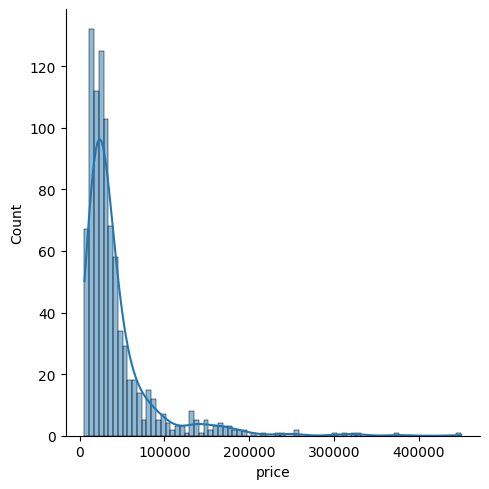

In [18]:
sns.displot(kind='hist',data=df,x='price',kde=True)

In [19]:
df['price'].skew()

np.float64(3.6560759858047662)

<Axes: ylabel='price'>

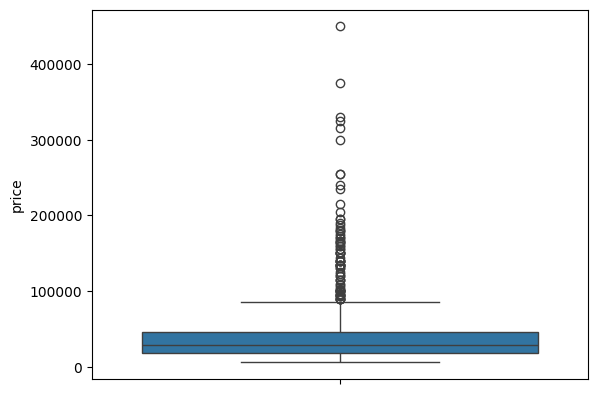

In [20]:
sns.boxplot(df['price'])

In [21]:
df[df['price'] > 250000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,ram_capacity,fast_charging_available,internal_memory,battery_capacity,fast_charging,screen_size,refresh_rate,resolution,primary_camera_front,primary_camera_rear,num_rear_cameras,num_front_cameras,os,extended_memory_available,extended_upto
2,apple,Apple iPhone Duo,299900,84.0,True,True,False,bionic,6.0,NaN,12,1,256,5800.0,NaN,7.6,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
24,apple,Apple iPhone Duo (2TB),449900,86.0,True,True,False,bionic,6.0,NaN,12,1,2048,5800.0,NaN,7.6,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
41,apple,Apple iPhone Duo (1TB),374900,85.0,True,True,False,bionic,6.0,NaN,12,1,1024,5800.0,NaN,7.6,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
63,apple,Apple iPhone 18 Pro Max (1TB),254900,88.0,True,True,False,bionic,6.0,NaN,12,1,1024,5391.0,NaN,6.9,120,1320 x 2868,18.0,48.0,3,1.0,ios,0,NaN
72,apple,Apple iPhone 18 Pro Max (2TB),329900,89.0,True,True,False,bionic,6.0,NaN,12,1,2048,5391.0,NaN,6.9,120,1320 x 2868,18.0,48.0,3,1.0,ios,0,NaN
144,apple,Apple iPhone Duo (512GB),324900,85.0,True,True,False,bionic,6.0,NaN,12,1,512,5800.0,NaN,7.6,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
185,apple,Apple iPhone 18 Pro (2TB),314900,88.0,True,True,False,bionic,6.0,NaN,12,1,2048,4056.0,NaN,6.3,120,1206 x 2622,18.0,48.0,3,1.0,ios,0,NaN
271,samsung,Samsung Galaxy Z Fold 8 Ultra (16GB RAM + 1TB),254999,98.0,True,True,False,snapdragon,8.0,4.74,16,1,1024,5000.0,45.0,8.0,120,2256 x 2504,10.0,200.0,3,2.0,android,0,NaN


In [22]:
df['price'].isnull().sum()

np.int64(0)

In [23]:
df['rating'].describe()

,rating
count,753.000000
mean,68.253652
std,11.545271
min,50.000000
25%,59.000000
50%,66.000000
75%,75.000000
max,98.000000


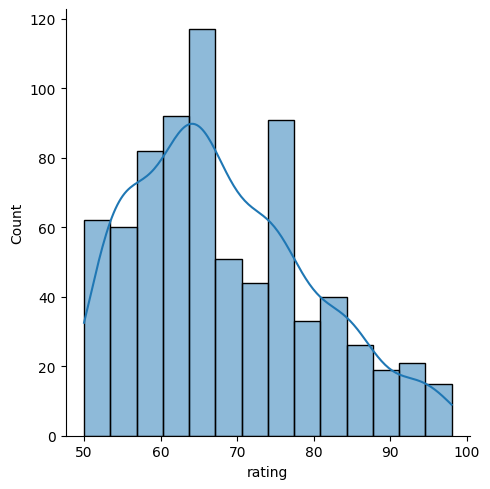

In [24]:
sns.displot(kind='hist',data=df,x='rating',kde=True)

In [25]:
df['rating'].skew()

np.float64(0.5474524309048235)

<Axes: ylabel='rating'>

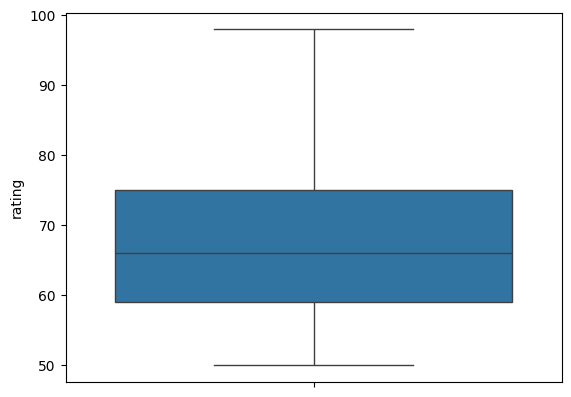

In [26]:
sns.boxplot(df['rating'])

In [27]:
df['rating'].isnull().sum()/980
# 13% missing values

np.float64(0.13673469387755102)

In [28]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,ram_capacity,fast_charging_available,internal_memory,battery_capacity,fast_charging,screen_size,refresh_rate,resolution,primary_camera_front,primary_camera_rear,num_rear_cameras,num_front_cameras,os,extended_memory_available,extended_upto
0,apple,Apple iPhone 18 Pro,164900,85.0,True,True,False,bionic,6.0,NaN,12,1,256,4056.0,NaN,6.30,120,1206 x 2622,18.0,48.0,3,1.0,ios,0,NaN
1,vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,True,False,True,snapdragon,8.0,2.8,8,1,256,6500.0,90.0,6.77,120,1080 x 2392,32.0,50.0,3,1.0,android,0,NaN
2,apple,Apple iPhone Duo,299900,84.0,True,True,False,bionic,6.0,NaN,12,1,256,5800.0,NaN,7.60,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
3,apple,Apple iPhone 18 Pro Max,179900,86.0,True,True,False,bionic,6.0,NaN,12,1,256,5391.0,NaN,6.90,120,1320 x 2868,18.0,48.0,3,1.0,ios,0,NaN
4,realme,Realme P1 5G (8GB RAM+ 128GB),14999,58.0,True,False,False,dimensity,8.0,2.6,8,1,128,5000.0,45.0,6.67,120,1080 x 2400,16.0,50.0,2,1.0,android,1,2048.0


<Axes: ylabel='count'>

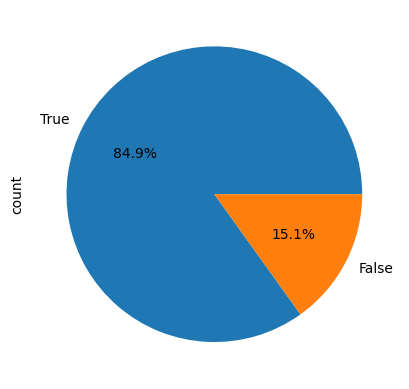

In [29]:
# has_5g
df['has_5g'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

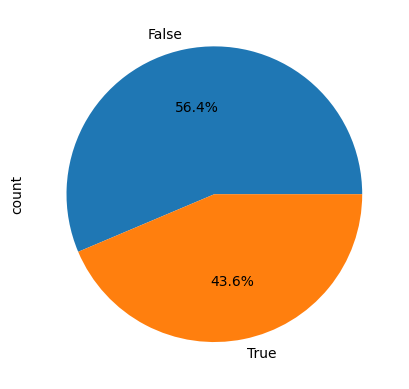

In [30]:
# has_nfc
df['has_nfc'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

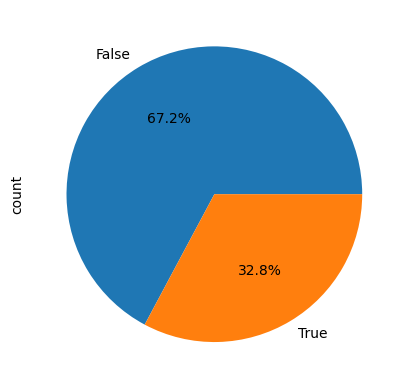

In [31]:
# has_ir_blaster
df['has_ir_blaster'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [32]:
df[df['has_ir_blaster'] == True]['brand_name'].value_counts()

,count
brand_name,
xiaomi,59
oppo,46
vivo,41
poco,36
realme,32
oneplus,25
tecno,17
iqoo,17
infinix,13


<Axes: ylabel='count'>

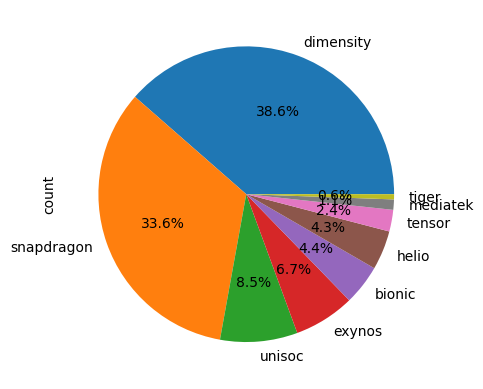

In [33]:
# processor_brand
df['processor_brand'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

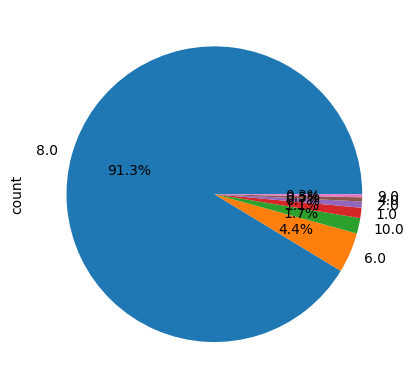

In [34]:
df['num_cores'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

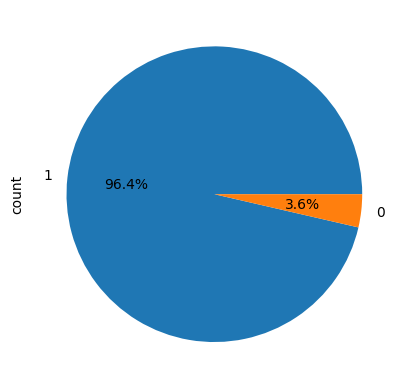

In [35]:

df['fast_charging_available'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

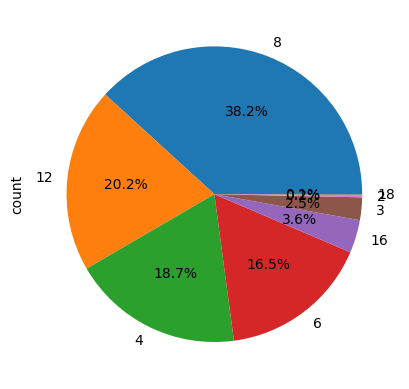

In [36]:
df['ram_capacity'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

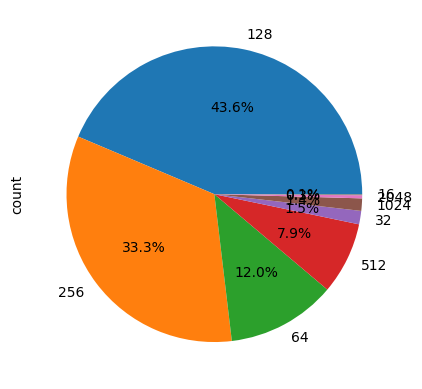

In [37]:
df['internal_memory'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

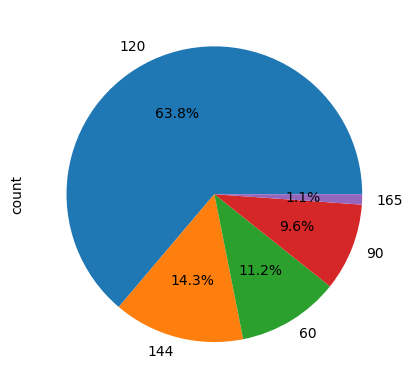

In [38]:
df['refresh_rate'].value_counts().plot(kind='pie',autopct="%0.1f%%")

In [39]:
df['refresh_rate'].value_counts()

,count
refresh_rate,
120,566
144,127
60,99
90,85
165,10


<Axes: ylabel='count'>

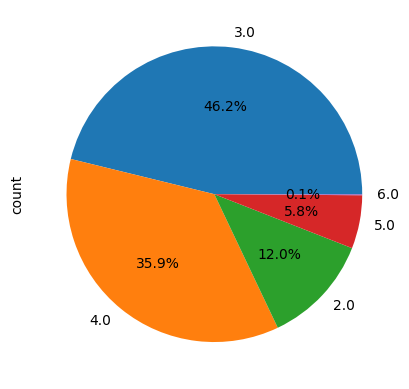

In [40]:
(df['num_rear_cameras'] + df['num_front_cameras']).value_counts().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='count'>

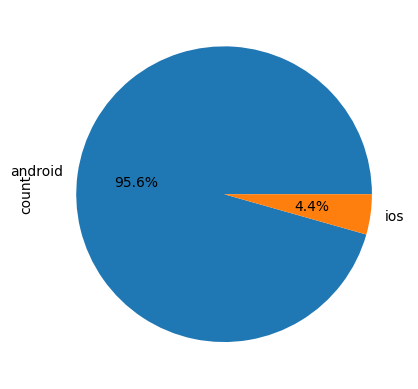

In [41]:
df['os'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

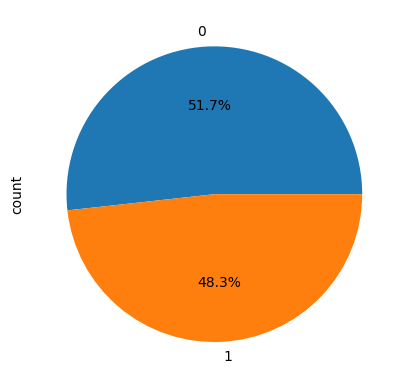

In [42]:
# extended_memory_available
df['extended_memory_available'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

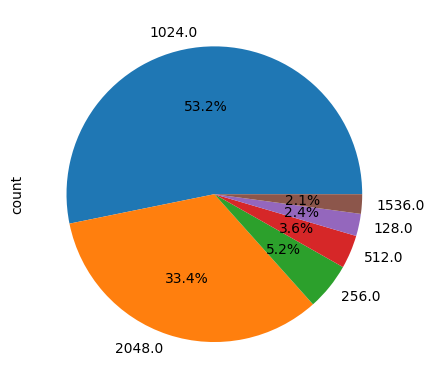

In [43]:
df['extended_upto'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [44]:
def plot_graphs(column_name):

  sns.displot(kind='hist',kde=True,data=df,x=column_name,label=column_name)
  sns.catplot(kind='box',data=df,x=column_name)

In [45]:
num_columns = df.select_dtypes(include=['float64','int64']).iloc[:,[3,4,6,9,13,14,16]].columns

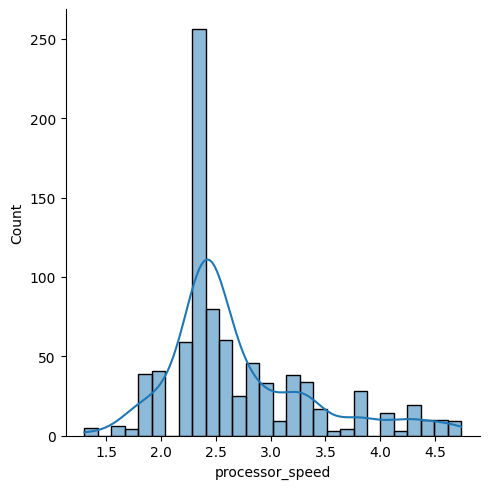

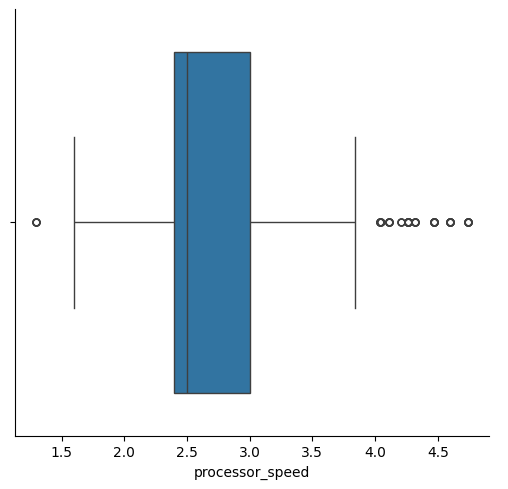

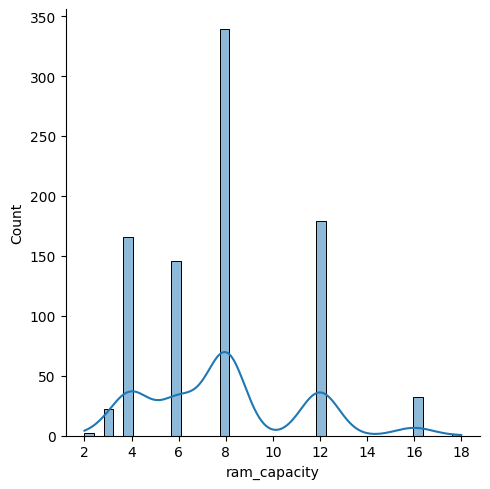

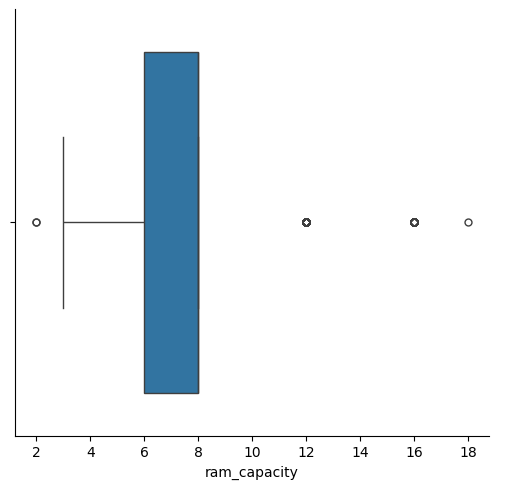

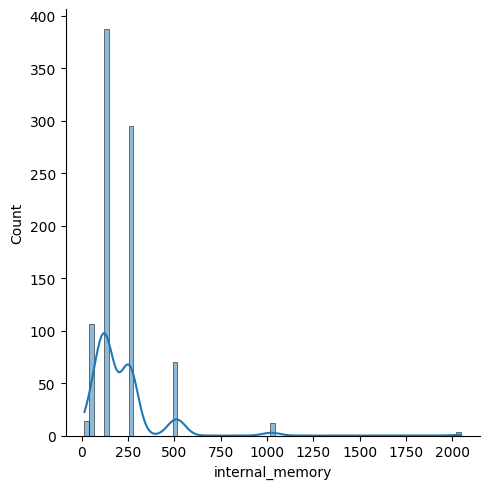

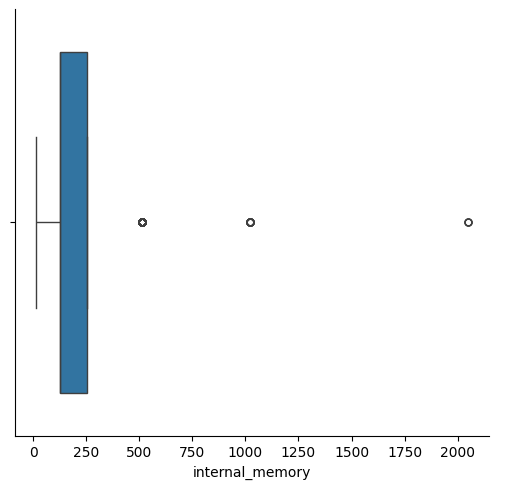

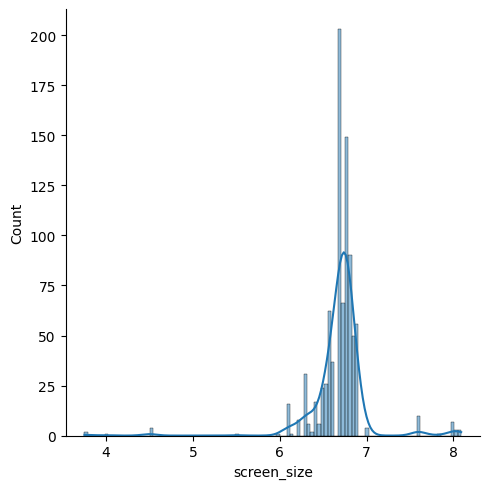

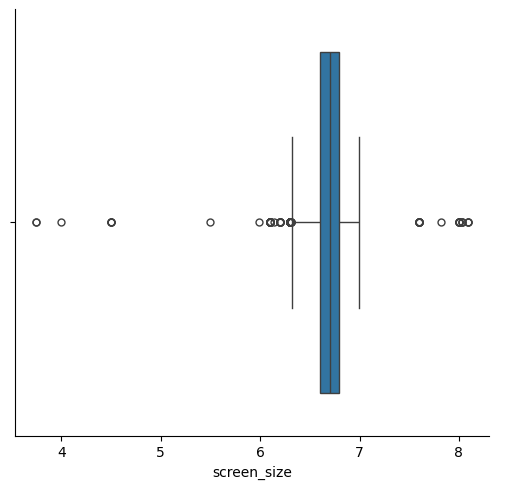

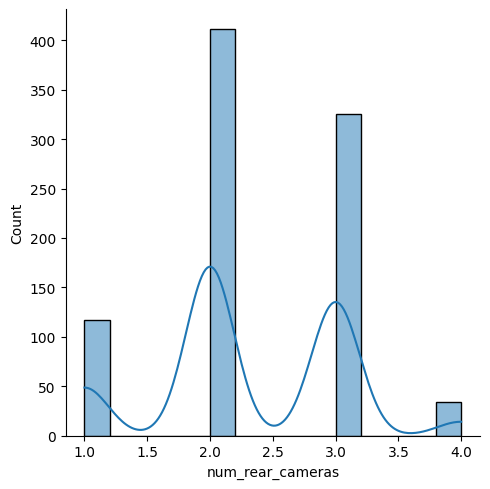

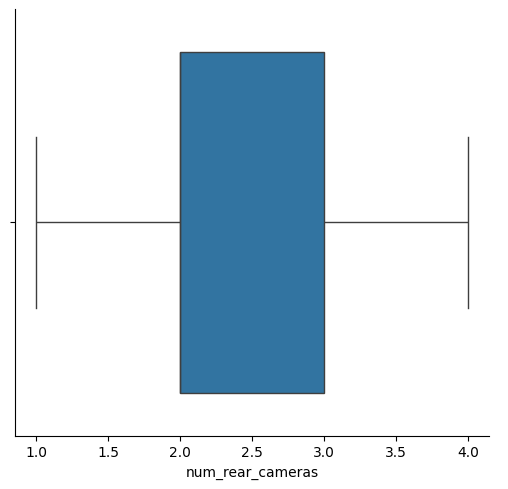

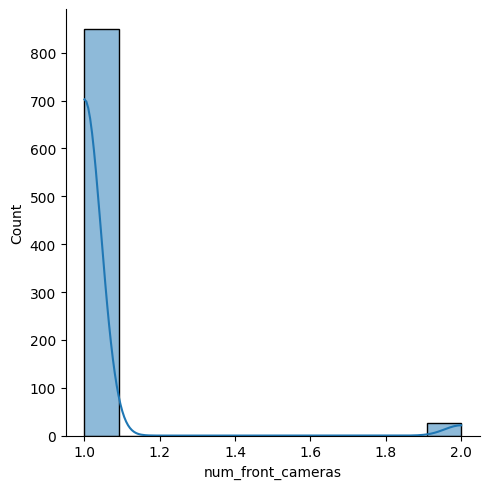

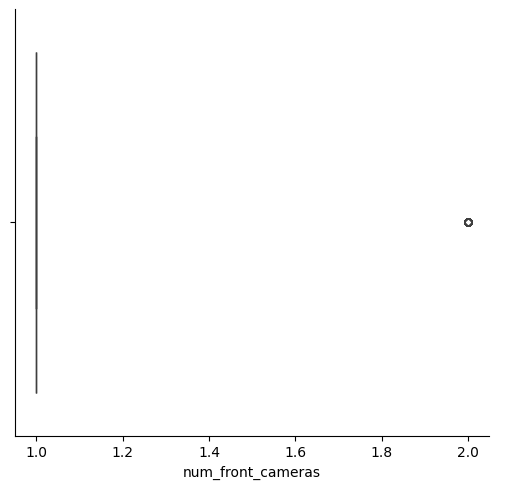

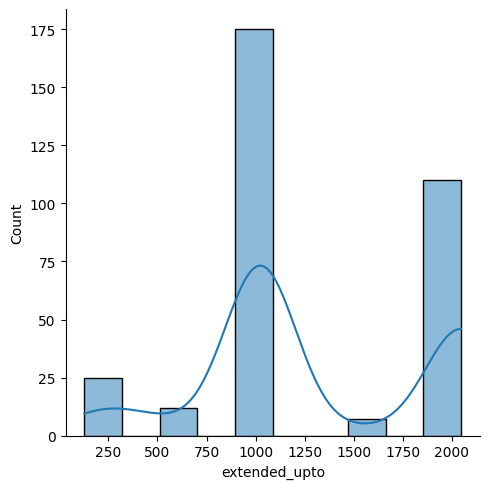

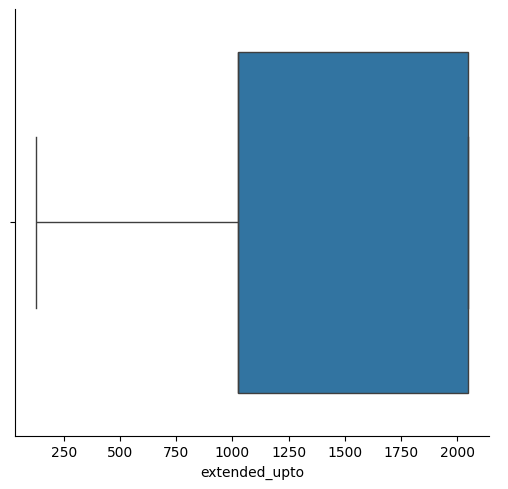

In [46]:
for col in num_columns:
  plot_graphs(col)

In [47]:
# All univariate anaysis done

In [48]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,ram_capacity,fast_charging_available,internal_memory,battery_capacity,fast_charging,screen_size,refresh_rate,resolution,primary_camera_front,primary_camera_rear,num_rear_cameras,num_front_cameras,os,extended_memory_available,extended_upto
0,apple,Apple iPhone 18 Pro,164900,85.0,True,True,False,bionic,6.0,NaN,12,1,256,4056.0,NaN,6.30,120,1206 x 2622,18.0,48.0,3,1.0,ios,0,NaN
1,vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,True,False,True,snapdragon,8.0,2.8,8,1,256,6500.0,90.0,6.77,120,1080 x 2392,32.0,50.0,3,1.0,android,0,NaN
2,apple,Apple iPhone Duo,299900,84.0,True,True,False,bionic,6.0,NaN,12,1,256,5800.0,NaN,7.60,120,1878 x 2670,12.0,48.0,2,2.0,ios,0,NaN
3,apple,Apple iPhone 18 Pro Max,179900,86.0,True,True,False,bionic,6.0,NaN,12,1,256,5391.0,NaN,6.90,120,1320 x 2868,18.0,48.0,3,1.0,ios,0,NaN
4,realme,Realme P1 5G (8GB RAM+ 128GB),14999,58.0,True,False,False,dimensity,8.0,2.6,8,1,128,5000.0,45.0,6.67,120,1080 x 2400,16.0,50.0,2,1.0,android,1,2048.0


# Bivariate Analysis

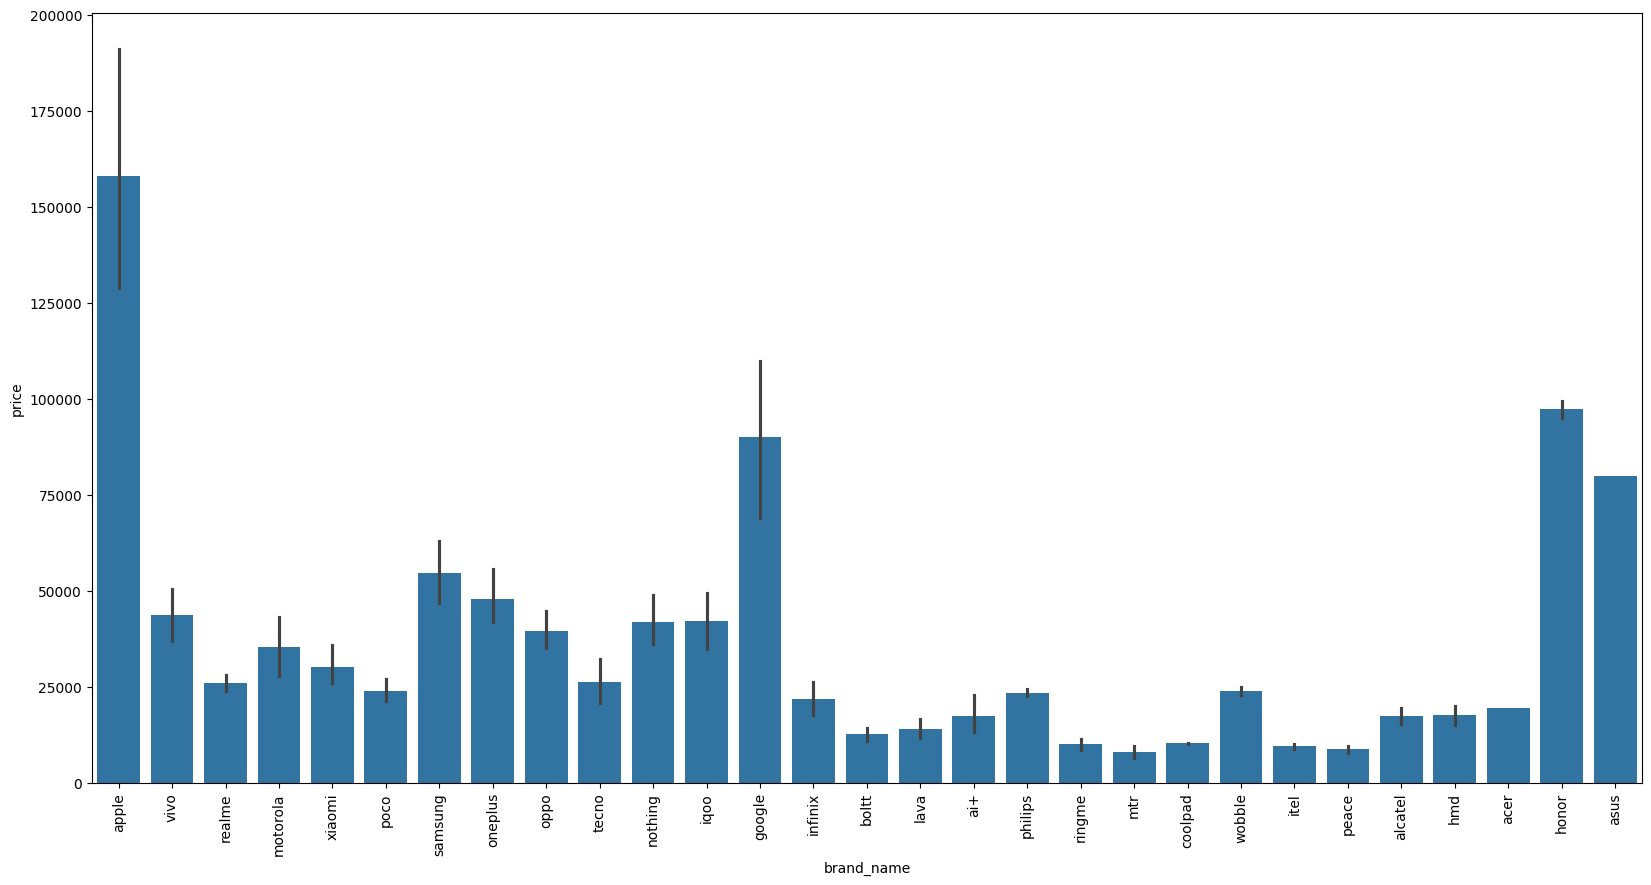

In [50]:
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='brand_name',y='price')
plt.xticks(rotation='vertical')
plt.show()

In [69]:
x = df.groupby('brand_name')['model'].count()

In [83]:
temp_df = df[df['brand_name'].isin(x[x > 10].index)]

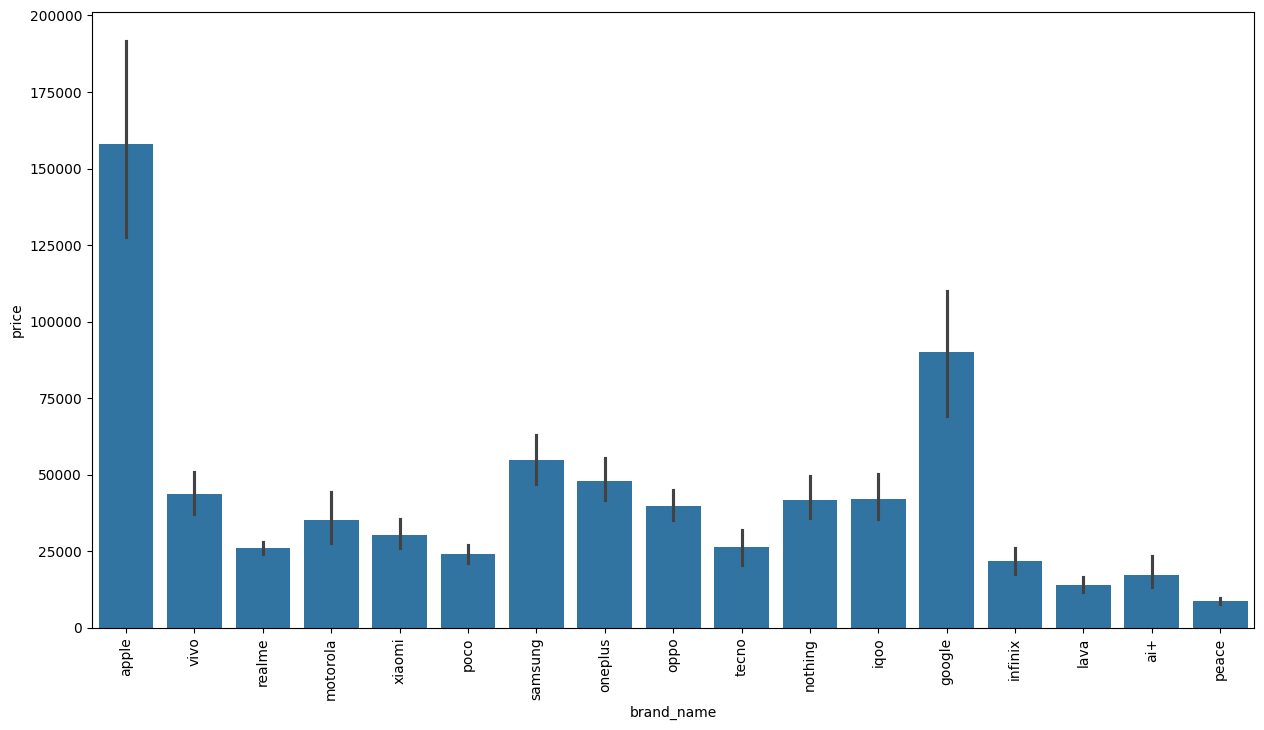

In [91]:
plt.figure(figsize=(15,8))
sns.barplot(data=temp_df,x='brand_name',y='price')
plt.xticks(rotation='vertical')
plt.show()

## Price and Rating (Numerical vs numerical columns)

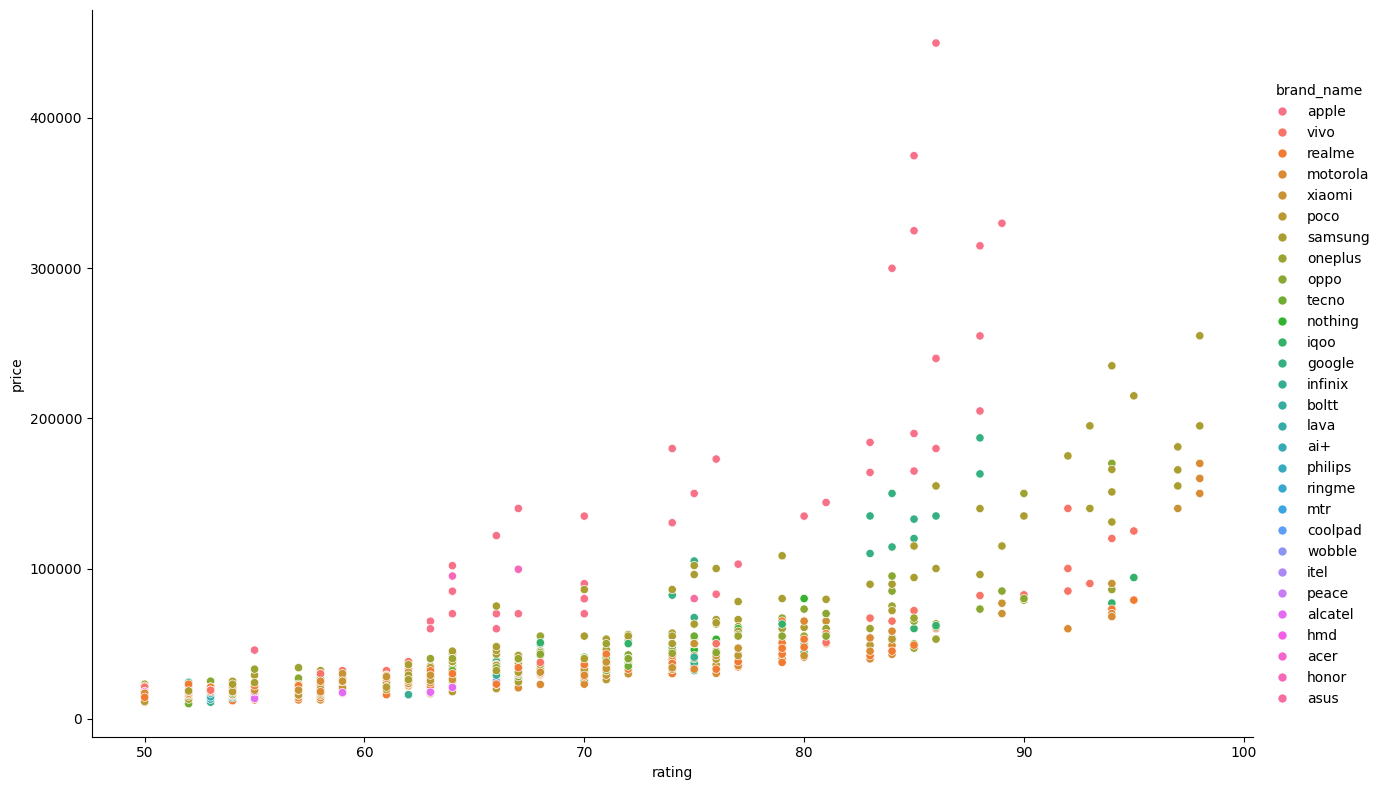

In [97]:
sns.relplot(
    data=df,
    x='rating',
    y='price',
    hue='brand_name',
    kind='scatter',
    height=8,
    aspect=1.6
)

<Axes: xlabel='has_5g', ylabel='price'>

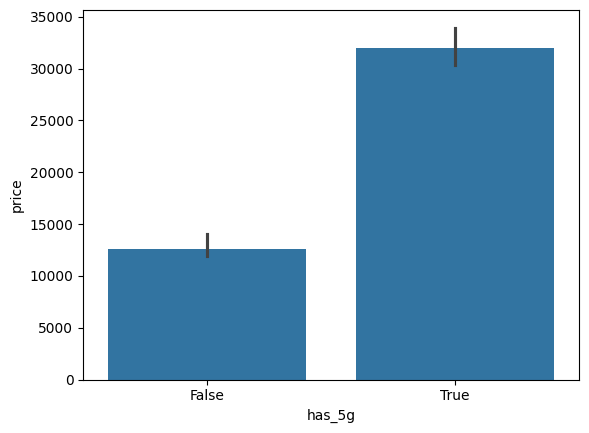

In [99]:
sns.barplot(data=temp_df,x='has_5g',y='price',estimator=np.median)

<Axes: xlabel='has_nfc', ylabel='price'>

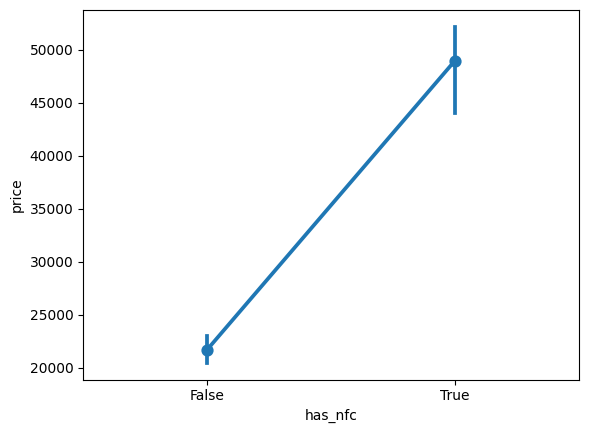

In [101]:
sns.pointplot(data=temp_df,x='has_nfc',y='price',estimator=np.median)

<Axes: xlabel='has_ir_blaster', ylabel='price'>

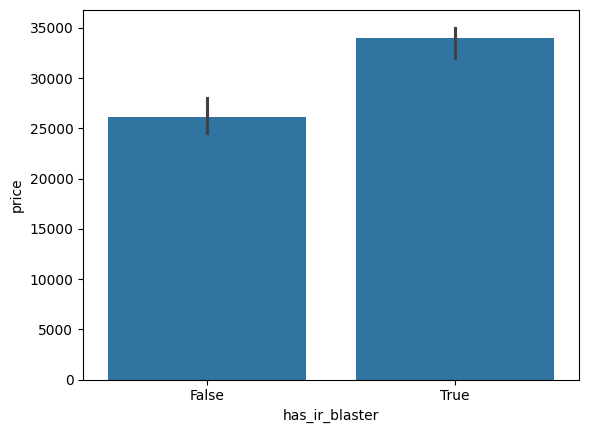

In [103]:
sns. barplot(data=temp_df,x='has_ir_blaster',y='price',estimator=np.median)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'bionic'),
  Text(1, 0, 'snapdragon'),
  Text(2, 0, 'dimensity'),
  Text(3, 0, 'exynos'),
  Text(4, 0, 'helio'),
  Text(5, 0, 'unisoc'),
  Text(6, 0, 'tensor'),
  Text(7, 0, 'tiger'),
  Text(8, 0, 'mediatek')])

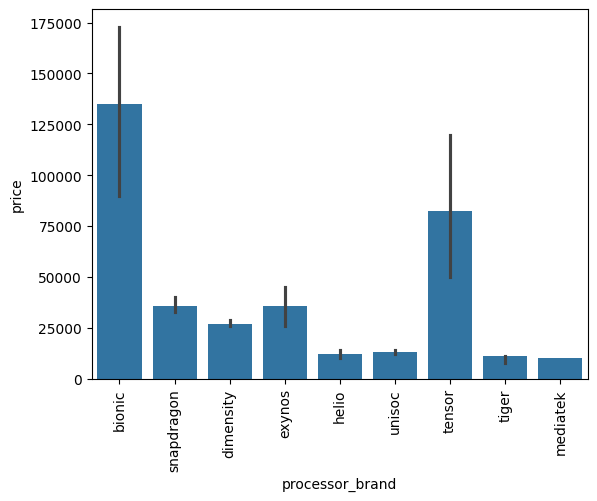

In [105]:
sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median)
plt.xticks(rotation='vertical')

[]

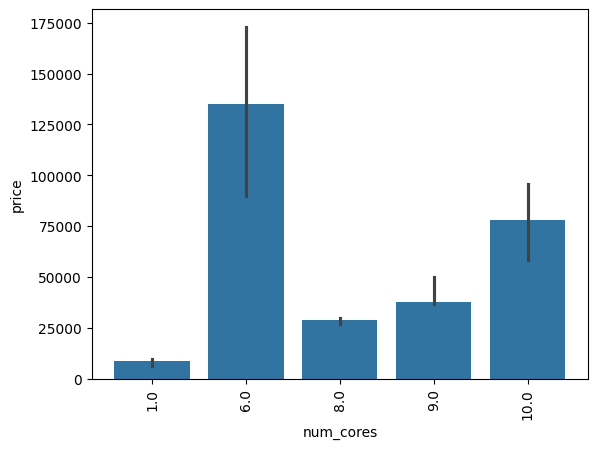

In [108]:
sns.barplot(data=temp_df,x='num_cores',y='price',estimator=np.median)
plt.xticks(rotation='vertical')
plt.plot()

In [109]:
pd.crosstab(df['num_cores'],df['os'])

os,android,ios
num_cores,,
1.0,10,0
2.0,6,0
4.0,4,0
6.0,0,39
8.0,810,0
9.0,3,0
10.0,15,0


<Axes: xlabel='processor_speed', ylabel='price'>

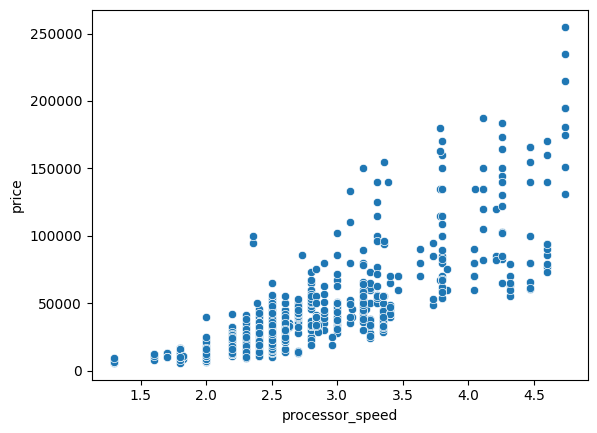

In [110]:
sns.scatterplot(data=df,x='processor_speed',y='price')

<Axes: xlabel='screen_size', ylabel='price'>

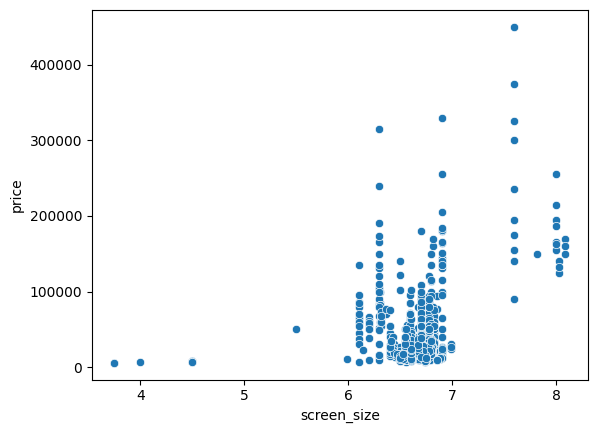

In [111]:
sns.scatterplot(data=df,x='screen_size',y='price')